In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *

# This library
from compressibleSPH import *
from compressibleSPH.modules.timestep.compressible import computeTimestep

# The case utilities that contain all the case setup functions for the various test cases
from compressibleSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.15.0.dev0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "aarch64"
   Kernel cache:
     /home/frieren/.cache/warp/1.15.0.dev0


In [2]:
R = 1
A = 1
B = 1
T = 4.827 * A

L = 2 *3 * R

nx = 192
dx = L / nx
targetDt = 0.00025
rho0 = 1
freeSurface = True
band = 0
fps = 50
timeLimit = T

dim = 2
n_h = 4


extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'rho0': rho0,

    'R': R,
    'A': A,
    'B': B,
    'T': T
    
}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()



dx = L / (nx)
band = 0

domain = buildDomainDescription(L + dx * (band) * 2, dim, True, device, dtype)
interiorDomain = buildDomainDescription(L, dim, False, device, dtype)

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx + band * 2
config.dx = (interiorDomain.max[0] - interiorDomain.min[0]) / (nx)

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = WeaklyCompressibleSPHScheme.deltaSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()


schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False

schemeConfig.surfaceDetectionConfig.active = True

In [4]:
schemeConfig.gravityConfig.active = True
schemeConfig.gravityConfig.type = GravityType.PotentialField
schemeConfig.gravityConfig.magnitude = B
schemeConfig.gravityConfig.origin =[0.0, 0.0]

No fluid particles found. Returning original state.


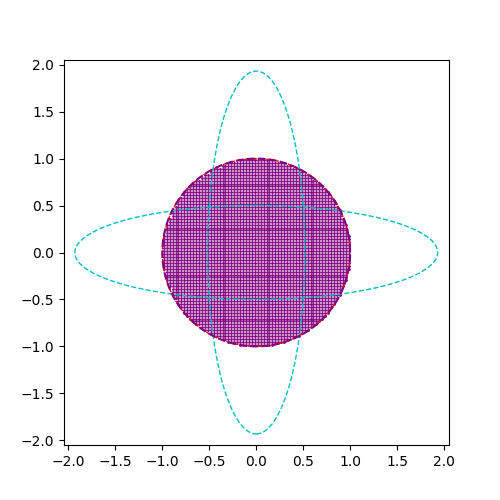

In [5]:



fluid_a = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('circle')['function'](x, torch.tensor(R).to(points.device)), torch.tensor([0,0.]).to(points.device)), invert = False)
# fluid_b = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('circle')['function'](x, torch.tensor(1/2).to(points.device)), torch.tensor([0.75,0.]).to(points.device)), invert = False)


regions = []

regions.append(buildRegion(config, schemeConfig, fluid_a, RegionType.Fluid, initialConditions = {}))

for region in regions:
    region = filterRegion(region, regions)


for region in regions:
    region = filterRegion(region, regions)

    


fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
    
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)

rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)

import matplotlib.patches as patches

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())
for ax in axis.flatten():
    initialElipse = patches.Ellipse((0,0), 2*R, 2*R, fill = False, edgecolor = 'r', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    maxWidthElipse = patches.Ellipse((0,0), 1.931843 * 2*R, R, fill = False, edgecolor = 'c', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    maxHeightElipse = patches.Ellipse((0,0), 2 / 1.931843 * R, 1.931843 * 2 * R, fill = False, edgecolor = 'c', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    ax.add_patch(initialElipse)
    ax.add_patch(maxWidthElipse)
    ax.add_patch(maxHeightElipse)
for ax in axis.flatten():
    ax.set_xlim(-2.05*R, 2.05*R)
    ax.set_ylim(-2.05*R, 2.05*R)


compressibleSystem = initializeWeaklyCompressibleSimulation(regions, config, schemeConfig, SimulationSystem, SimulationState, verbose = True)

In [6]:
compressibleSystem.state.velocities[:,0] = A * compressibleSystem.state.positions[:,0]
compressibleSystem.state.velocities[:,1] = -A * compressibleSystem.state.positions[:,1]


In [7]:
nu_inviscid = alphaToNu(schemeConfig.diffusionParams.inviscidAlpha, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
alpha_effective = nuToAlpha(schemeConfig.diffusionParams.viscidNu, schemeConfig.fluid.fixedSoundSpeed, compressibleSystem.state.supports.mean().cpu().item(), config.dim)
print(f"nu_inviscid: {nu_inviscid}, alpha_effective: {alpha_effective}")

nu_inviscid: 0.0015625, alpha_effective: 0.0064


In [8]:
# compressibleSystem.state.positions = shuffleParticles(compressibleSystem.state, config, schemeConfig, 128, jitterAmount = 0.5)

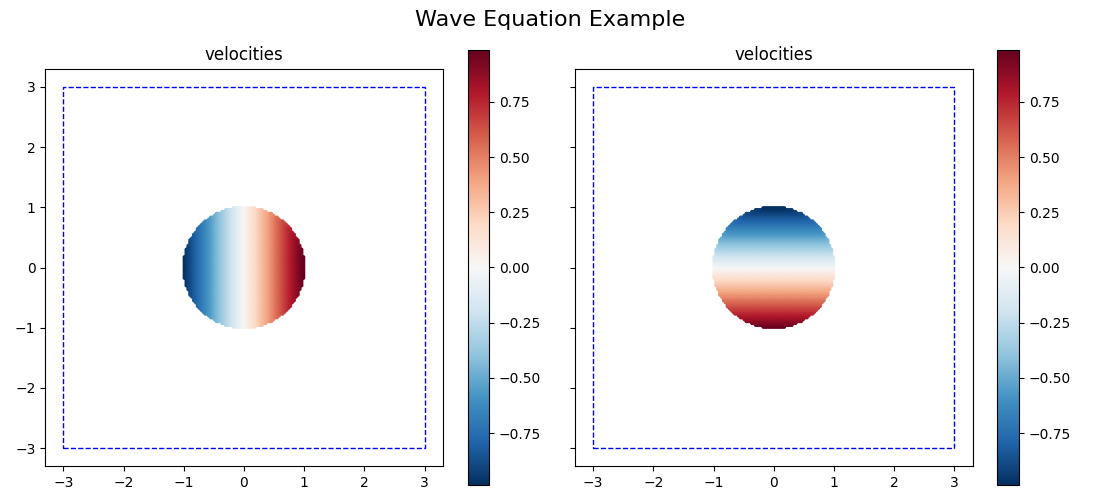

In [9]:
runningState = compressibleSystem.initializeNewState()

from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap,VisualizeOptions
markerSize = 4
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.velocities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.x,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            #     streamLines = True
            # ),
            # boundaryVisualization = VisualizeOptions.Visualize,
            # # vMin=1e-10,
            # stream
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "velocities",
            mapping = Mapping.y,
            # plottingOperation = OperationProperties(
            #     operation = WarpOperation.Curl,
            #     kernel = config.kernel,
            #     supportMode = SupportScheme.Gather, # cullen switch E.1 in the CRK paper uses gather for density estimation
            # ),
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='matplotlib',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)


# imagePath = f'{exportPath}/images'
# os.makedirs(imagePath, exist_ok = True)
# plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)

In [10]:
runningState = compressibleSystem.initializeNewState()
from compressibleSPH.modules.timestep.weaklyCompressible import computeTimestep

config.dt = computeTimestep(
    system = compressibleSystem,
    config = config,
    compParams = schemeConfig,
    dt = 1e-4,
    systemUpdate = None,
)
print(config.dt)

tensor(0.0017)


In [11]:
caseName = 'oscillatingDroplet'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    'frame_num': 0,
}, **extraData))

In [12]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap, CyclicColorMap
markerSize = 8
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            boundaryVisualization = VisualizeOptions.Visualize,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.flare,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            boundaryVisualization = VisualizeOptions.Hide,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)


RFBOutputContext()

In [13]:
runningState = compressibleSystem.initializeNewState()
ke = torch.sum(0.5 * runningState.state.densities * torch.sum(runningState.state.velocities**2, dim=1)) / torch.sum(runningState.state.densities)

schemeConfig.diffusionParams.inviscid = True
schemeConfig.diffusionParams.nu = 0.01
# schemeConfig.shiftProperties.active = False
schemeConfig.fluid.eosType = EquationOfState.stiffTait

schemeConfig.shiftProperties.projectionScheme = ShiftingProjectionScheme.mat
schemeConfig.surfaceDetectionConfig.scheme = SurfaceDetectionScheme.Barecasco
schemeConfig.shiftProperties.computeMach = True

In [15]:
nSteps = int(timeLimit / config.dt)

runningState = compressibleSystem.initializeNewState()

kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    # begin = torch.cuda.Event(enable_timing=True)
    # end = torch.cuda.Event(enable_timing=True)
    # begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    # end.record()
    # torch.cuda.synchronize()
    priorStep = result.stages[-1]
    # timing = begin.elapsed_time(end)

    runningState = result.state

    if i % 10 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.UIDs,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{timeLimit:8.4g} | max vel: {maxVel:.3g}")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



  0%|          | 0/2794 [00:00<?, ?it/s]

Module sphWarpCore.radiusSearch.wp_compactHash eaa5a9a load on device 'cpu' took 104.43 ms  (cached)
Module sphWarpCore.operations.wp_interpolate 49ab1a9 load on device 'cpu' took 1826.98 ms  (compiled)
Module sphWarpCore.operations.wp_gradient 54171f0 load on device 'cpu' took 1438.42 ms  (compiled)
Module compressibleSPH.modules.surfaceDetection.wp_barecasco e21ee7f load on device 'cpu' took 2137.52 ms  (compiled)
Module compressibleSPH.modules.surfaceDetection.wp_dilate 431a224 load on device 'cpu' took 1269.51 ms  (compiled)
Module sphWarpCore.renorm.wp_covariance 8466595 load on device 'cpu' took 1708.28 ms  (compiled)
Module compressibleSPH.modules.deltaSPH.wp_densityDelta df67ae2 load on device 'cpu' took 2058.56 ms  (compiled)
Module compressibleSPH.modules.deltaSPH.wp_viscosityDelta afe6c3a load on device 'cpu' took 1636.71 ms  (compiled)
Module sphWarpCore.operations.wp_divergence 6bae12a load on device 'cpu' took 1304.01 ms  (compiled)
Module compressibleSPH.modules.pressure

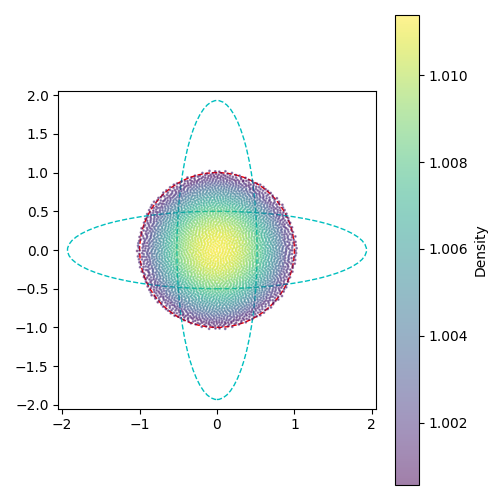

In [15]:

fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
    
rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)


for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())
for ax in axis.flatten():
    initialElipse = patches.Ellipse((0,0), 2*R, 2*R, fill = False, edgecolor = 'r', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    maxWidthElipse = patches.Ellipse((0,0), 1.931843 * 2*R, R, fill = False, edgecolor = 'c', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    maxHeightElipse = patches.Ellipse((0,0), 2 / 1.931843 * R, 1.931843 * 2 * R, fill = False, edgecolor = 'c', linewidth = 1, linestyle = '--')#.set_clip_box(axis['A'].bbox)
    ax.add_patch(initialElipse)
    ax.add_patch(maxWidthElipse)
    ax.add_patch(maxHeightElipse)
for ax in axis.flatten():
    ax.set_xlim(-2.05*R, 2.05*R)
    ax.set_ylim(-2.05*R, 2.05*R)

sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = runningState.state.densities.cpu().numpy(), alpha = 0.5)

fig.colorbar(sc, ax = axis[0,0], label = 'Density')


fig.tight_layout()

In [ ]:

    
fs, fsm, n = detectFreeSurface(runningState.state, config, schemeConfig, schemeConfig.surfaceDetectionConfig, None, returnNormals = True)


Module sphWarpCore.operations_grid.wp_interpolate_grid d2796eb load on device 'cuda:0' took 3.07 ms  (cached)
Module sphWarpCore.operations_grid.wp_gradient_grid 681ff8f load on device 'cuda:0' took 3716.34 ms  (compiled)


In [34]:
adjacency = buildVerletList(
        runningState.state, 
        config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
        priorNeighborhood = None,
        verbose = False)

C, Evals, renormalizationState_ = computeRenormalizationMatrices(
    queryParticles = runningState.state,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        operationMode = OperationDirection.AllToAll,
        supportMode = SupportScheme.SuperSymmetric
    ),
    domain = config.domain,
    adjacency = adjacency,
    returnEigVals = True
)
lMin = torch.min(torch.abs(Evals), dim = -1).values

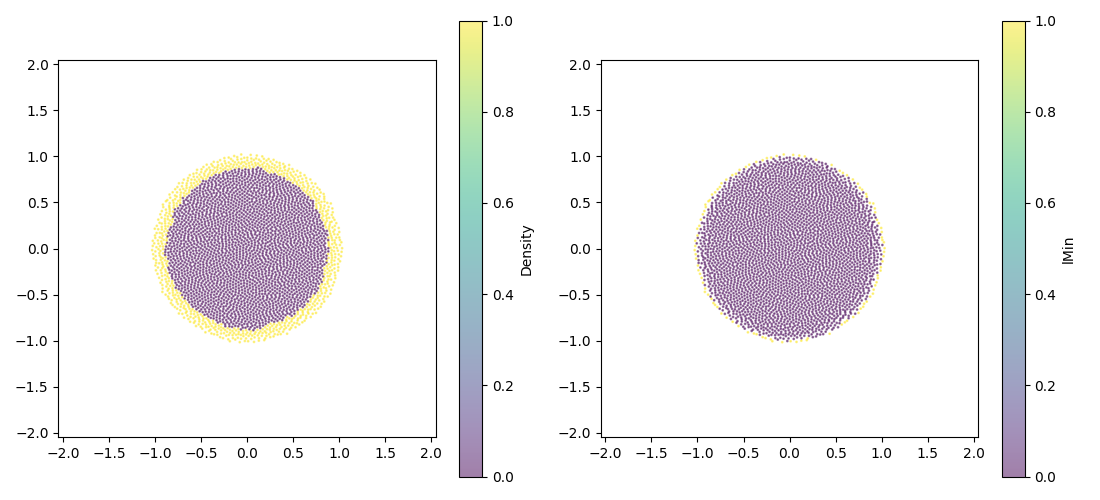

In [ ]:


fig, axis = plt.subplots(1, 2, figsize=(11, 5), squeeze=False)
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())
for ax in axis.flatten():
    ax.set_xlim(-2.05*R, 2.05*R)
    ax.set_ylim(-2.05*R, 2.05*R)
    
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = fsm.cpu().numpy() > 0.5, alpha = 0.5)

fig.colorbar(sc, ax = axis[0,0], label = 'Density')

sc = axis[0,1].scatter(runningState.state.positions[:,0].cpu().numpy(), runningState.state.positions[:,1].cpu().numpy(), s = 1, c = lMin.cpu().numpy() < 0, alpha = 0.5)
fig.colorbar(sc, ax = axis[0,1], label = 'lMin')


fig.tight_layout()

In [24]:
display(schemeConfig.surfaceDetectionConfig)
display(schemeConfig.shiftProperties)

SurfaceDetectionConfig(active=True, colorFieldThreshold=0.75, colorFieldGradThreshold=10.0, barecascoThreshold=1.5, expansionIterations=1, scheme=<SurfaceDetectionScheme.ColorFieldGrad: 1>, normalSource=<NormalSource.ColorFieldGrad: 1>)

ShiftProperties(iterations=1, CFL=0.3, computeMach=False, maxC=0.3, active=True, scheme=<ShiftingScheme.deltaSPH: 1>, projectionScheme=<ShiftingProjectionScheme.mat: 2>, summationDensity=False, surfaceScaling=0.1, threshold=0.5, projectQuantities=False)

In [ ]:

# exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
#     'frame_num': i,
# }))

In [30]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 120 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

'export/randomVelocityFieldBoundedDiffBC/output.mp4'